# Sales Prediction Project
# Author: Udit Gupta
# Goal: Predict Store Sales using Machine Learning


In [ ]:
!git clone https://github.com/Udit-23122004/rossmann-sales-prediction.git
%cd rossmann-sales-prediction

Cloning into 'rossmann-sales-prediction'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 1), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 7.23 MiB | 7.43 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (13/13), done.
/content/rossmann-sales-prediction/rossmann-sales-prediction/rossmann-sales-prediction/rossmann-sales-prediction


In [ ]:
!pip install xgboost


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor


In [ ]:
df=pd.read_csv('data/train.csv')
store=pd.read_csv('data/store.csv')

/tmp/ipykernel_6642/3475099498.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('data/train.csv')


In [ ]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [ ]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [ ]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
df=df.merge(store,on='Store',how='left')


df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
# Total missing values in cols
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [ ]:
# Handling missing values
df.fillna(0,inplace=True)


In [ ]:
# Total missing values in cols
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [ ]:
# Now Apply Feature Enginnering
df['Date']=pd.to_datetime(df['Date'])
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day
df['Week']=df['Date'].dt.isocalendar().week

In [ ]:
# remove closed stores
df=df[df['Open']==1]

In [ ]:
# For previous day sale we use lag faeture
df=df.sort_values(['Store','Date'])
df['Lag_1']=df.groupby('Store')['Sales'].shift(1)
df.dropna(inplace=True)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Encode catgeorical data
df=pd.get_dummies(df,drop_first=True)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 843277 entries, 1013865 to 1114
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Store                           843277 non-null  int64         
 1   DayOfWeek                       843277 non-null  int64         
 2   Date                            843277 non-null  datetime64[ns]
 3   Sales                           843277 non-null  int64         
 4   Customers                       843277 non-null  int64         
 5   Open                            843277 non-null  int64         
 6   Promo                           843277 non-null  int64         
 7   SchoolHoliday                   843277 non-null  int64         
 8   CompetitionDistance             843277 non-null  float64       
 9   CompetitionOpenSinceMonth       843277 non-null  float64       
 10  CompetitionOpenSinceYear        843277 non-null  float64 

In [ ]:
# Train Test split
# it is time series data we can't randomly split
# if split it randomly then if 2016 will be at train and 2014 at test
# first past year come after that future
train=df[df['Year']<2015]
test=df[df['Year']>=2015]

X_train=train.drop(['Sales','Date'],axis=1)
y_train=train['Sales']

X_test=test.drop(['Sales','Date'],axis=1)
y_test=test['Sales']

In [ ]:
X_train.shape

(647245, 29)

In [ ]:
X_test.shape

(196032, 29)

In [ ]:
#Model Training (XGBoost)
from xgboost import XGBRegressor

model=XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Pediction
pred=model.predict(X_test)

In [ ]:
# Model Evaluation

from sklearn.metrics import mean_absolute_error,r2_score

print("MAE",mean_absolute_error(y_test,pred))
print("R2 Score:",r2_score(y_test,pred))


MAE 510.927978515625
R2 Score: 0.9442171454429626


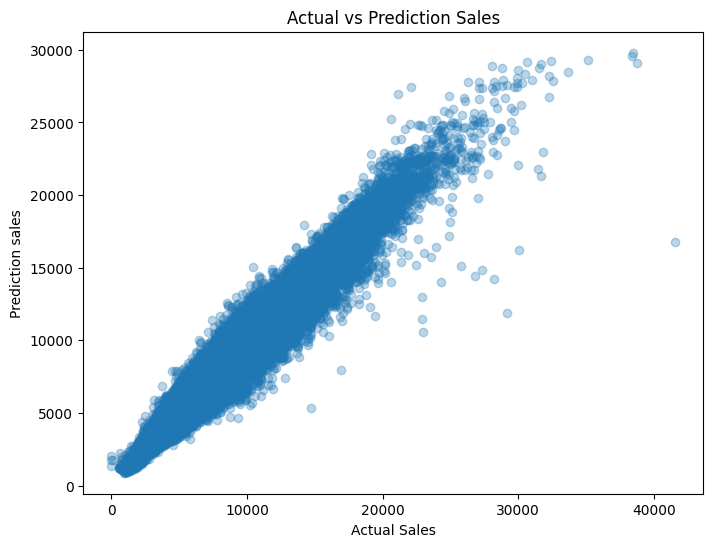

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,pred,alpha=0.3)
plt.xlabel("Actual Sales")
plt.ylabel("Prediction sales")
plt.title("Actual vs Prediction Sales")
plt.show()

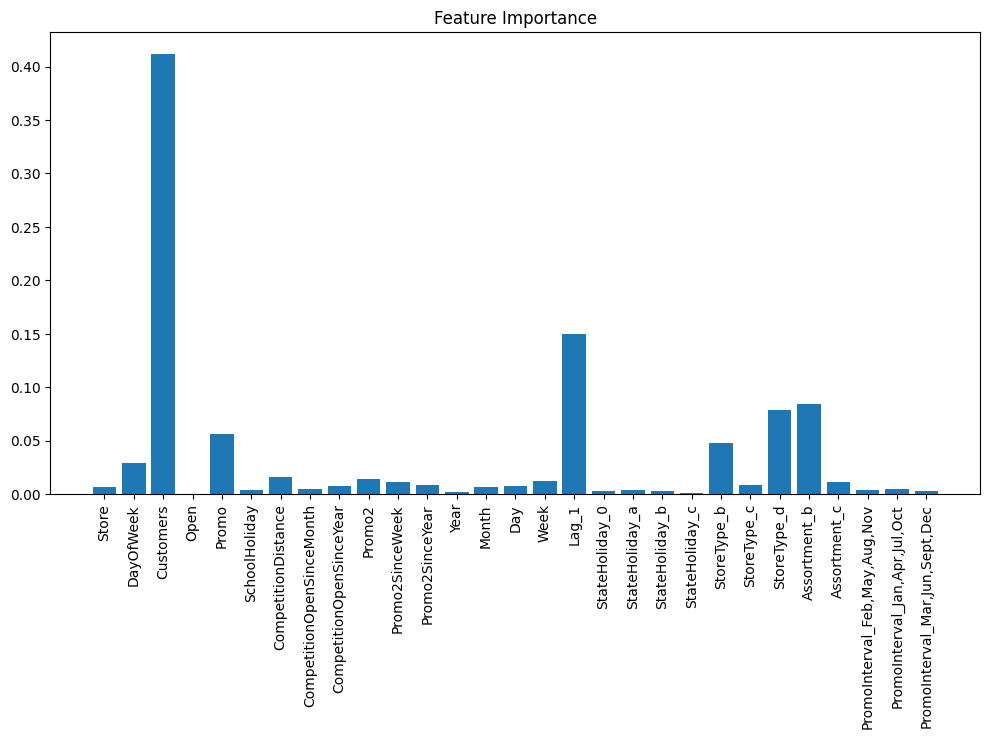

In [ ]:
importances=model.feature_importances_

plt.figure(figsize=(12,6))
plt.bar(X_train.columns,importances)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

In [ ]:
# Lag_7 (Last week sale)
df['Lag_7']=df.groupby('Store')['Sales'].shift(7)

In [ ]:
# Rolling Mean (Last 7 days average)
df['Rolling_Mean_7']=df.groupby('Store')['Sales'].shift(1).rolling(7).mean()

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params={
    'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[200,300]
}
grid=GridSearchCV(XGBRegressor(),params,cv=3)
grid.fit(X_train,y_train)

print(grid.best_params_)

In [ ]:
import pickle
pickle.dump(model, open("final_sales_model.pkl", "wb"))

In [ ]:
import os
os.listdir()

In [ ]:
import pickle

loaded_model = pickle.load(open("final_sales_model.pkl", "rb"))

In [ ]:
prediction = loaded_model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

print("R2 after loading:", r2_score(y_test, prediction))

In [ ]:
# first row of test dataset
sample_input = X_test.iloc[0:1]


In [ ]:
# the row provided to model and it provide output sale of that row
loaded_model.predict(sample_input)

In [ ]:
pred_value = loaded_model.predict(sample_input)[0]

print("Actual:", y_test.iloc[0])
print("Predicted:", pred_value)